In [1]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [6]:
veri = pd.read_csv("IMDB_Dataset.csv")
yorumlar=veri["review"]
print(veri.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [23]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords") #stopwords veri setini indir
stop_words=set(stopwords.words("english"))

#metin temizleme
def metin_temizle(metin):
  metin=metin.lower()
  metin=re.sub(r"\d++","",metin) #sayıları kaldır
  metin=re.sub(r"[^\w\s]","",metin) #özel karakterleri kaldır
  metin= " ".join([kelime for kelime in metin.split() if len(kelime)>2 and kelime not in stop_words]) #kısa kelimeleri sil
  return metin

#yorumları temizle
temizlenmis_yorumlar=[metin_temizle(y) for y in yorumlar]
print(temizlenmis_yorumlar[:5])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['one reviewers mentioned watching episode youll hooked right exactly happened mebr first thing struck brutality unflinching scenes violence set right word trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordbr called nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awaybr would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle class inmates turne

In [24]:
#tokenization
tokenize_yorumlar=[simple_preprocess(y) for y in temizlenmis_yorumlar]

In [25]:
#word2vec modeli
word2vec_model= Word2Vec(
    sentences=tokenize_yorumlar, #eğitim verisi
    vector_size=50, #vektör boyutu
    window=5, min_count=1, sg=0
)

#eğitimden sonra kelime vektörleri al
kelime_vektorleri=word2vec_model.wv

#ilk 500 kelimeyi al
kelimeler=list(kelime_vektorleri.index_to_key)[:500]
vektorler=[kelime_vektorleri[w] for w in kelimeler]

In [26]:
#kmeans
kmeans=KMeans(n_clusters=2) #2 küme belirle
kmeans.fit(vektorler)
kume_etiketleri= kmeans.labels_ #her kelime için küme etiketi

In [27]:
#pca
pca= PCA(n_components=2)
indirgenmis_vektorler= pca.fit_transform(vektorler)

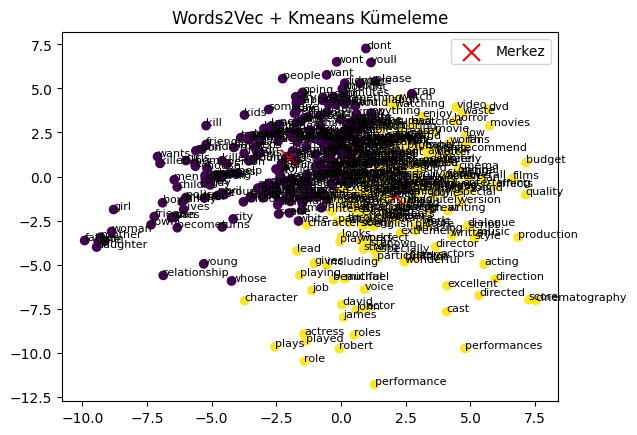

In [28]:
#görselleştirme
plt.figure()
plt.scatter(indirgenmis_vektorler[:,0], indirgenmis_vektorler[:,1], c= kume_etiketleri, cmap="viridis")

#küme merkezini işaretle
merkezler=pca.transform(kmeans.cluster_centers_)
plt.scatter(merkezler[:,0], merkezler[:,1], c="red", marker="x", s=150, label="Merkez")

for i, kelime in enumerate(kelimeler):
  plt.text(indirgenmis_vektorler[i,0], indirgenmis_vektorler[i,1], kelime, fontsize=8)

plt.title("Words2Vec + Kmeans Kümeleme")
plt.legend()
plt.show()